# Notebook 07 — Visualización de Predicciones a lo largo del tiempo
Este notebook permite visualizar gráficamente la correspondencia entre las crisis epilépticas reales (anotadas por el neurólogo) y las detectadas por el modelo, a lo largo del tiempo.

In [7]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('../'))
from src.models.classifiers import get_random_forest_pipeline
from src.models.hysteresis import apply_hysteresis_logic
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

### 1. Cargar datos de un paciente
Cargamos los datos procesados en orden cronológico.

In [8]:
PACIENTE = 'chb01'
DATA_DIR = '../data/processed'

X = np.load(os.path.join(DATA_DIR, f'X_{PACIENTE}_completo.npy'))
y = np.load(os.path.join(DATA_DIR, f'y_{PACIENTE}_completo.npy'))

print(f"Paciente {PACIENTE}")
print(f"Dimensiones X: {X.shape}")
print(f"Etiquetas y: {y.shape} (Crisis: {np.sum(y==1)})")

Paciente chb01
Dimensiones X: (291934, 276)
Etiquetas y: (291934,) (Crisis: 877)


### 2. Entrenamiento y Predicción Cronológica
Para ver cómo se comporta en la vida real, dividimos la línea de tiempo en dos: la primera mitad para que el modelo aprenda (Train), y la segunda para probarlo (Test).

In [9]:
# Split cronológico (70% train, 30% test)
split_idx = int(len(X) * 0.7)

X_train, y_train = X[:split_idx], y[:split_idx]
X_test, y_test = X[split_idx:], y[split_idx:]

print(f"Train: {len(y_train)} ventanas (Crisis: {np.sum(y_train==1)})")
print(f"Test: {len(y_test)} ventanas (Crisis: {np.sum(y_test==1)})")

# Balanceo solo en train
smote = SMOTE(sampling_strategy=0.1, random_state=42)
rus = RandomUnderSampler(sampling_strategy=0.5, random_state=42)

# Modelo base RF
clf = get_random_forest_pipeline(n_estimators=100, random_state=42)

# Pipeline con balanceo
pipeline = ImbPipeline([('smote', smote), ('rus', rus), ('clf', clf)])

# Entrenar
pipeline.fit(X_train, y_train)

# Predecir probabilidades para TODO el registro (para poder graficar completo)
y_pred_proba = pipeline.predict_proba(X)[:, 1]

# Aplicar histéresis a las probabilidades continuas
y_pred_smooth = apply_hysteresis_logic(y_pred_proba, N_windows=3, threshold_high=0.6, threshold_low=0.4)

Train: 204353 ventanas (Crisis: 877)
Test: 87581 ventanas (Crisis: 0)


### 3. Visualización de la Línea de Tiempo
Comparamos la etiqueta real vs la detectada.

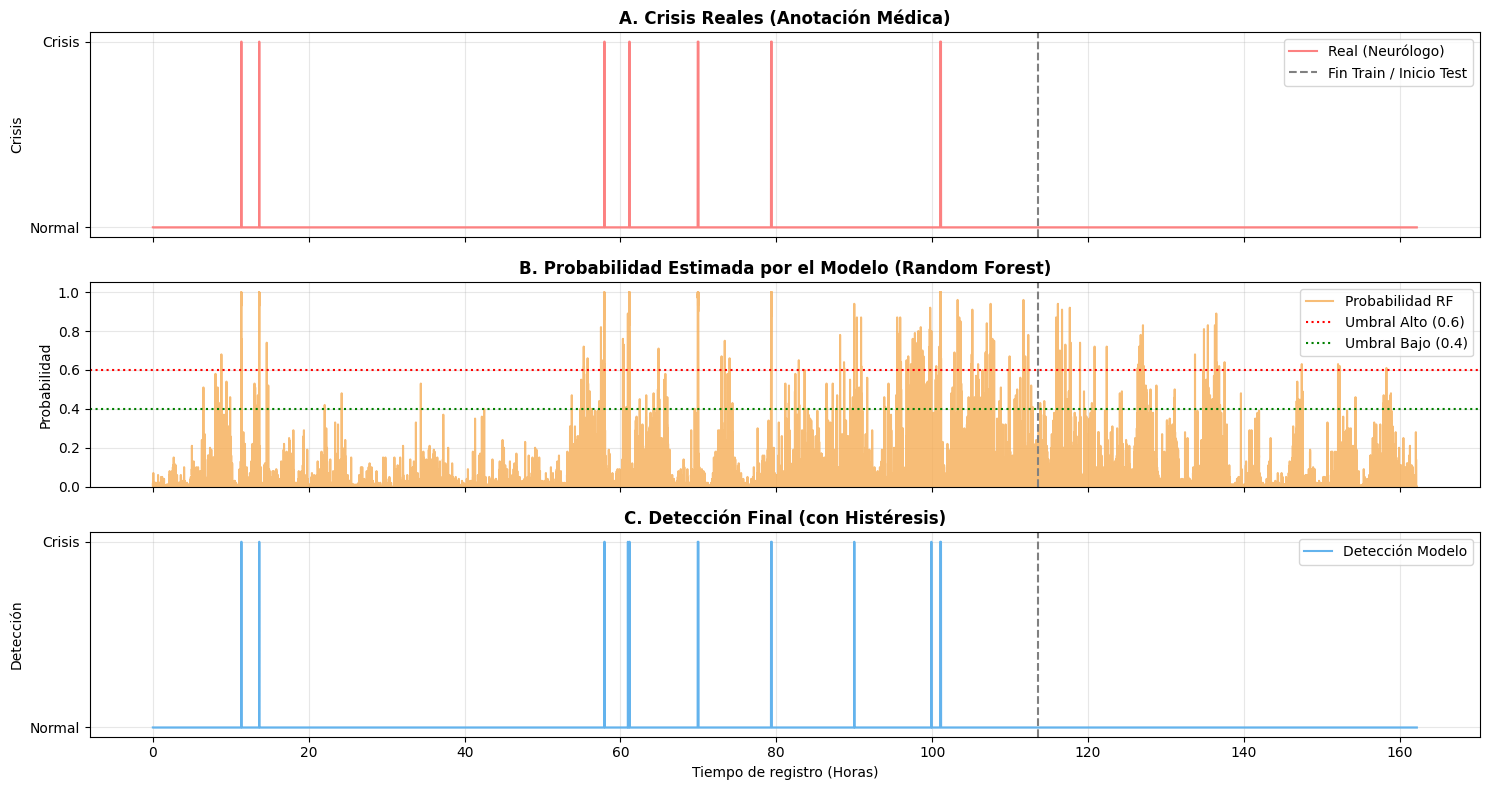

In [10]:
# Calculamos el tiempo real en horas
# Asumiendo ventana de 4s y overlap de 2s (avance de 2s por ventana)
AVANCE_S = 2.0
tiempo_horas = (np.arange(len(y)) * AVANCE_S) / 3600.0

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

# 1. Etiquetas reales del neurólogo
ax1.plot(tiempo_horas, y, color='#fc8181', label='Real (Neurólogo)', linewidth=1.5)
ax1.fill_between(tiempo_horas, 0, y, color='#fc8181', alpha=0.3)
ax1.set_title('A. Crisis Reales (Anotación Médica)', fontweight='bold')
ax1.set_ylabel('Crisis')
ax1.set_yticks([0, 1])
ax1.set_yticklabels(['Normal', 'Crisis'])
ax1.grid(True, alpha=0.3)
ax1.axvline(tiempo_horas[split_idx], color='gray', linestyle='--', label='Fin Train / Inicio Test')
ax1.legend(loc='upper right')

# 2. Probabilidad cruda del modelo
ax2.plot(tiempo_horas, y_pred_proba, color='#f6ad55', label='Probabilidad RF', alpha=0.8)
ax2.axhline(0.6, color='red', linestyle=':', label='Umbral Alto (0.6)')
ax2.axhline(0.4, color='green', linestyle=':', label='Umbral Bajo (0.4)')
ax2.set_title('B. Probabilidad Estimada por el Modelo (Random Forest)', fontweight='bold')
ax2.set_ylabel('Probabilidad')
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)
ax2.axvline(tiempo_horas[split_idx], color='gray', linestyle='--')
ax2.legend(loc='upper right')

# 3. Detección final (con Histéresis)
ax3.plot(tiempo_horas, y_pred_smooth, color='#63b3ed', label='Detección Modelo', linewidth=1.5)
ax3.fill_between(tiempo_horas, 0, y_pred_smooth, color='#63b3ed', alpha=0.3)
ax3.set_title('C. Detección Final (con Histéresis)', fontweight='bold')
ax3.set_ylabel('Detección')
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['Normal', 'Crisis'])
ax3.set_xlabel('Tiempo de registro (Horas)')
ax3.grid(True, alpha=0.3)
ax3.axvline(tiempo_horas[split_idx], color='gray', linestyle='--')
ax3.legend(loc='upper right')

plt.tight_layout()
plt.savefig('../reports/figures/07_timeline_predicciones.png', dpi=150)
plt.show()